# Parameter tuning for Duck

## Paths and settings

In [1]:
new_initial_state = False
new_tuning = True

In [2]:
# paths jupyter utwente
path_tc = '/home/jovyan/data/98_paper2_kf_dtm/01_tides/output/'
path_validation = '/home/jovyan/data/98_paper2_kf_dtm/02_Duck_validation_data/'

path_input_general = '/home/jovyan/data/98_paper2_kf_dtm/0_input_general/'
path_input = '/home/jovyan/data/98_paper2_kf_dtm/22_23_Duck_DEM/input/'
path_output = '/home/jovyan/data/98_paper2_kf_dtm/22_23_Duck_DEM/output/'
path_altimetry_output = '/home/jovyan/data/98_paper2_kf_dtm/21_Duck_altimetry/output/'

# filenames for gebco and DeltaDTM
fn_gebco = 'gebco_2024_n36.6257_s35.7784_w-76.1201_e-75.3896.nc'
fn_ddtm = 'DeltaDTM_v1_0_N36W076.tif'

In [3]:
epsg = 4326 # WGS84

year_start = 1993
year_end = 2020 # included

# Suppress warning about mean of empty slice
# but might suppress other warnings as well
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Imports

In [4]:
%load_ext autoreload
%autoreload 2

import pdb

import os
import pickle
import pandas as pd
import geopandas as gpd
import numpy as np
import xarray as xr
import time
import itertools

from scipy import stats

from shapely import LineString
from shapely.ops import split

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import colormaps as cm
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

from coastal_data import CD_statistics, CD_combine_data, \
    CD_geometry, CD_kalman, CD_jarkus_tools, CD_visualisation

/home/jovyan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [5]:
# matplotlib fontsizes
SMALL_SIZE = 15
MEDIUM_SIZE = 20
BIGGER_SIZE = 25
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)   # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)   # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)   # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

## Static parameters

In [6]:
# Define T as identity matrix or with spatial dependencies
T_is_identity = True # Use identity matrix
# T_is_identity = False # Model spatial dependencies

# T-matrix with spatial dependencies
# if not T_is_identity:
# All points within `max_distance` around the point of iterest (identitcal point)
# are considered neighbouring points
max_distance = 150

# Weight of the identical point in T
# (residual weight is equally distributed between neighbouring points)
w_id = 0.5

# Number of iterations where a grid point does not get updated in a row
# before infusing a pseudo observation from the initial state
max_noupdate = 5

# Standard deviation of pseudo-observations
std_pseudobs = 1 # [m]

# eps: parameter in function 'sparsify matrix'
# smallest absolute value allowed in a sparse matrix
# eps = mean(diag) / eps_factor
# only important if using T with spatial averaging
eps_factor = 1e9

## Observations

In [7]:
# Altimetry
fn = 'tp_plus_ales_epsg32618.csv'
alt = pd.read_csv(path_altimetry_output+fn, index_col='time', parse_dates=['time'])

In [8]:
# Tidal correction
fn = 'tides_duck.csv'
tidal_corr = pd.read_csv(path_tc+fn, index_col='dates', parse_dates=['dates'])

In [9]:
# Cassie shorelines
folders = ['1_1992-08-10_1995-02-24/',
          '2_1995-03-21_2001-03-12/',
          '3_2001-04-13_2009-03-18/',
          '4_2009-04-12_2018-02-07/',
          '5_2018-02-23_2025-03-06/']
sl_cassie = CD_combine_data.combine_cassie(path_input+'1_shorelines_cassie/', folders, epsg=epsg)

# Reduce shorelines to the altimetry period
idx, = np.where((np.array(sl_cassie['dates']) >= alt.index[0]) & (np.array(sl_cassie['dates']) <= alt.index[-1]))

c_dates = np.array(sl_cassie['dates'], dtype=object)[idx]
c_shorelines = np.array(sl_cassie['shorelines'], dtype=object)[idx]

# number of points per shoreline
n_sl_points = np.array([len(_) for _ in c_shorelines])
print(f"{len(c_shorelines)} Landsat/Cassie shorelines in total in the altimetry period. "
    f"Shorelines have on average {int(np.nanmean(n_sl_points))} points (min: {np.nanmin(n_sl_points)}, max: {np.nanmax(n_sl_points)}).")

180 Landsat/Cassie shorelines in total in the altimetry period. Shorelines have on average 90 points (min: 80, max: 215).


## Initial state

In [10]:
buffer_size = 500 # [m], buffer radius of target area around the set of shorelines
resolution = 50 # [m], resolution of the target grid in x- and y-direction
smooth_factor = 10 # Smoothing of shorelines used to compute the median shoreline
fn_init = f'init_{epsg}_resolution_{resolution}m.tif'
if (not os.path.isfile(path_output + fn_init)) | new_initial_state:    
    CD_kalman.initial_state(epsg, buffer_size, smooth_factor, resolution, c_shorelines, alt,
                            path_input+'2_global_DEMs/', path_output, fn_init, fn_gebco, fn_ddtm)

Always load `init`, even if it was computed in this go (otherwise there is one case where init is a dataframe, and one case where it is an xarray DataSet):

In [11]:
init = xr.open_dataset(path_output+fn_init).squeeze()

fn_poly_sl = f'poly_sl_{epsg}.pkl'
poly_sl = pickle.load(open(path_output + fn_poly_sl, 'rb'))

fn_target_poly = f'poly_buffered_{epsg}.pkl'
poly_target = pickle.load(open(path_output + fn_target_poly, 'rb'))    

init_df = init.to_dataframe()
x = init_df.index.get_level_values('x')
y = init_df.index.get_level_values('y')    
x_state = gpd.GeoDataFrame({'init': init_df.band_data.values}, geometry=gpd.points_from_xy(x, y))

In [12]:
poly_sl = pickle.load(open(path_output + f'poly_sl_{epsg}.pkl', 'rb'))
poly_target = pickle.load(open(path_output + f'poly_buffered_{epsg}.pkl', 'rb'))
med_sl = pickle.load(open(path_output + f'med_sl{epsg}.pkl', 'rb')) 

Text(0.5, 1.0, 'Initial state: GEBCO + DeltaDTM')

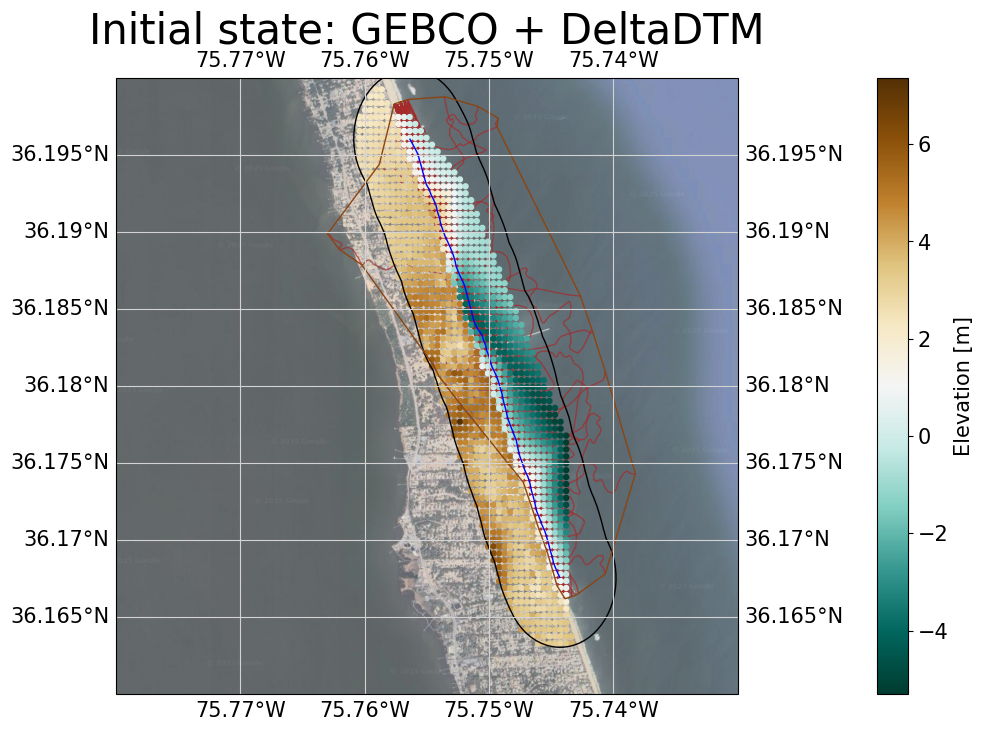

In [13]:
# Plot intial state
projection = ccrs.PlateCarree()
# extent = [-75.76, -75.735, 36.175, 36.19]
extent = [-75.78, -75.73, 36.16, 36.2]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)

for sl in c_shorelines:
    ax.add_geometries(LineString(sl), crs=projection, facecolor='none', edgecolor='brown', zorder=1, alpha=.7)
    
ax.add_geometries(poly_target, crs=projection, facecolor='none', edgecolor='black')
ax.add_geometries(poly_sl, crs=projection, facecolor='none', edgecolor='saddlebrown')
ax.add_geometries(med_sl, crs=projection, facecolor='none', edgecolor='blue')
    
plot = ax.scatter(x_state.geometry.x, x_state.geometry.y, c=x_state.init, transform=projection, marker='.', s=50,
                  cmap='BrBG_r') #, vmin=-10, vmax=10)
fig.colorbar(plot, shrink=1, pad=0.12, label='Elevation [m]')
ax.set_title('Initial state: GEBCO + DeltaDTM', fontsize=30)

# plt.savefig(f'{path_partun}initial_state.png', dpi=300, bbox_inches='tight')

## Shoreline outlier rejection

In [14]:
# shoreline outlier rejection
init_df = init.to_dataframe().reset_index().dropna()
zcontour = CD_geometry.get_DEM_contour(init_df['x'], init_df['y'], init_df['band_data'], h=0, tarea=poly_target)

t_factor = .8 # threshold = t_factor * mean, (mean of distances to reference shoreline), points inside that range are kept
c_shorelines_corr = CD_geometry.shoreline_outlier_rejection(c_shorelines, zcontour, epsg, t_factor)

38.0% of shoreline points were discarded.


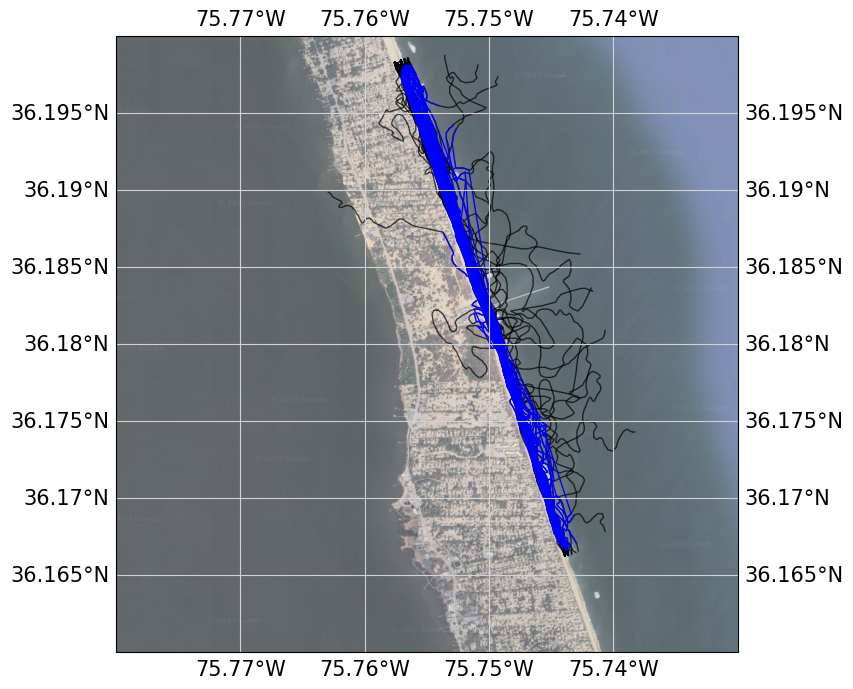

In [15]:
# Visual inspection of shoreline outlier rejection
projection = ccrs.PlateCarree()
extent = [-75.78, -75.73, 36.16, 36.2]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)

# ax.add_geometries(poly_sl, crs=projection, facecolor='none', edgecolor='orange')
# ax.add_geometries(poly_target, crs=projection, facecolor='none', edgecolor='black')

for sl in c_shorelines:
    ax.add_geometries(LineString(sl), crs=projection, facecolor='none', edgecolor='black', zorder=1, alpha=.7)
for sl in c_shorelines_corr:
    ax.add_geometries(LineString(sl), crs=projection, facecolor='none', edgecolor='blue', zorder=1, alpha=1)

## Validation data

In [16]:
duck_vali = xr.open_dataset(path_validation+'duck_validation.nc')

# Reduce to time after 1992
vali_years = pd.to_datetime(duck_vali.time).year
idx_time, = np.where((vali_years >= year_start) & (vali_years <= year_end))
duck_vali = duck_vali.isel(time=idx_time)

In [96]:
# xarray DataSet to GeoDataFrame
lon_vali = duck_vali.longitude.values.reshape(-1)
lat_vali = duck_vali.latitude.values.reshape(-1)

elev_vali = duck_vali['elevation'].values.reshape(len(duck_vali.time), len(duck_vali.xFRF)*len(duck_vali.yFRF))

dates = pd.to_datetime(duck_vali.time)
vali_df = pd.DataFrame(elev_vali, index=dates)

# yearly means anchored in June
# https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases
valid_df_yearly = vali_df.groupby(pd.Grouper(freq='YE-JUN')).mean()
valid_df_yearly.index = valid_df_yearly.index.year

vali_gdf = gpd.GeoDataFrame(valid_df_yearly.T, geometry=gpd.points_from_xy(lon_vali, lat_vali))
vali_gdf = vali_gdf.set_crs('4326')
vali_gdf.columns = [str(_) for _ in vali_gdf.columns]

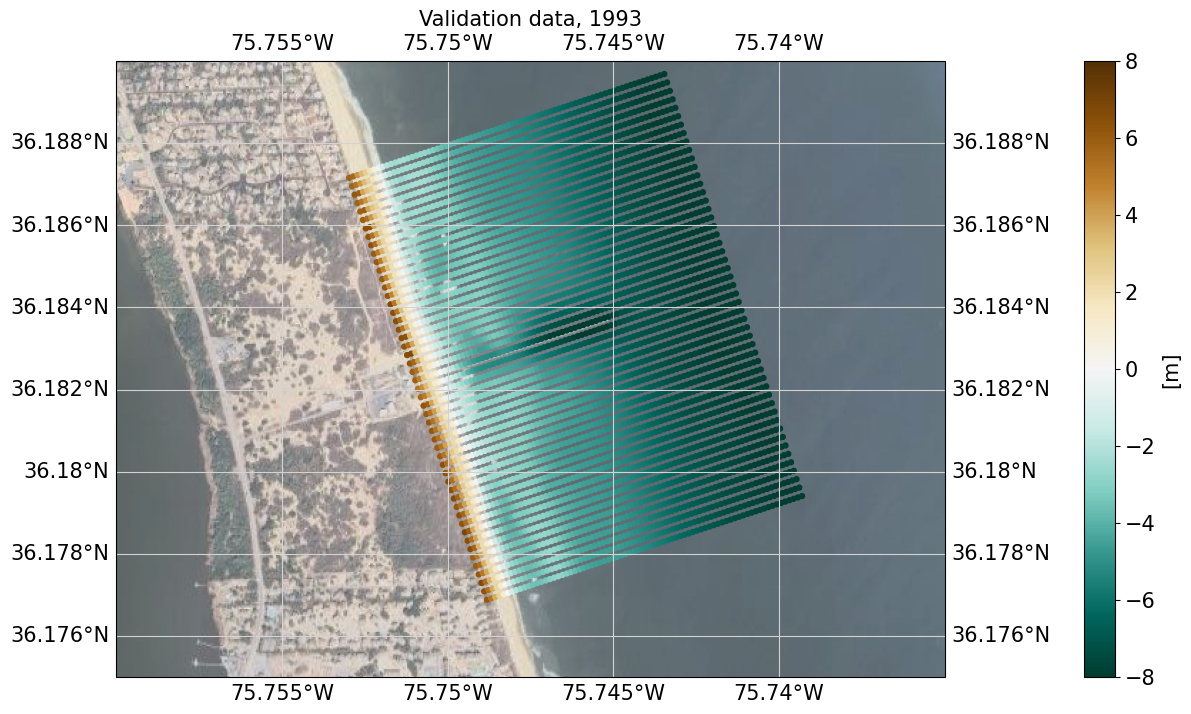

In [100]:
date = '1993'

projection = ccrs.PlateCarree()
extent = [-75.76, -75.735, 36.175, 36.19]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)

plot = ax.scatter(vali_gdf.geometry.x, vali_gdf.geometry.y, c=vali_gdf[date],
                  transform=projection, marker='.', s=50, cmap='BrBG_r', vmin=-8, vmax=8)
fig.colorbar(plot, shrink=1, pad=0.12, label='[m]')
ax.set_title(f'Validation data, {date}');

## Functions for volume changes

In [104]:
def volume_changes(x_state, x_state_s, vali_gdf, poly_target_red):
    start_time = time.perf_counter()
    
    # Volumes for all (sub)areas
    year_list = [int(_) for _ in kf_interp.drop(columns='geometry').columns]

    volumes = pd.DataFrame(index=year_list)

    volumes['kf'] = CD_geometry.compute_volume_changes(x_state, poly_target_red, col_name='', epsg_out=32618)
    volumes['rts'] = CD_geometry.compute_volume_changes(x_state_s, poly_target_red, col_name='', epsg_out=32618)
    volumes['vali'] = CD_geometry.compute_volume_changes(vali_gdf, poly_target_red, col_name='', epsg_out=32618)

    # Volume timeseries statistics
    rmse = CD_statistics.RMSE_timeseries(volumes[f"rts"], volumes[f"vali"])
    corr, pvalues = stats.pearsonr(volumes[f"rts"], volumes[f"vali"])

    # Volume timeseries trends
    trends = {}
    Cxxs = {}
    vs = {}

    variables = ['kf', 'rts', 'vali']

    for variable in variables:
        trends[variable], Cxxs[variable], vs[variable] = CD_statistics.compute_trend_with_error(volumes.index.values.astype(int), volumes[variable].values)

    # Trend error (from VLM notebook)
    # Quntile of t-distribution
    alpha = 0.05
    f = len(volumes) - 1  # degrees of freedom
    quantile = stats.t.ppf(alpha, f)

    n = len(volumes)

    def compute_std(v):
        return np.sqrt(np.sum((v ** 2)) / (n - 1))

    errors = {}
    for key, value in vs.items():
        errors[key] = quantile * (compute_std(value) / np.sqrt(n))

    # Alternative, taking std from least-squares estimate covariance matrix: Cxx[0,0]
    # results in magnitudes 1e9
    # quantile*(Cxxs['kf_all'][0,0]/np.sqrt(n))

    end_time = time.perf_counter()
    ex_time = end_time - start_time
    print("Volume changes done. Needed ", round(ex_time,1), "seconds.")
       
    return volumes, rmse, corr, pvalues, trends, errors

## Define area for volume change

In [42]:
buffer_vol = -350 # [m]
buffer_vol = CD_geometry.dist_meter_to_dist_deg(buffer_vol)
poly_target_red = poly_target.buffer(buffer_vol)
print(f'Reduced target polygon by {round(1-(poly_target_red.area / poly_target.area), 3)*100} %')

Reduced target polygon by 73.8 %


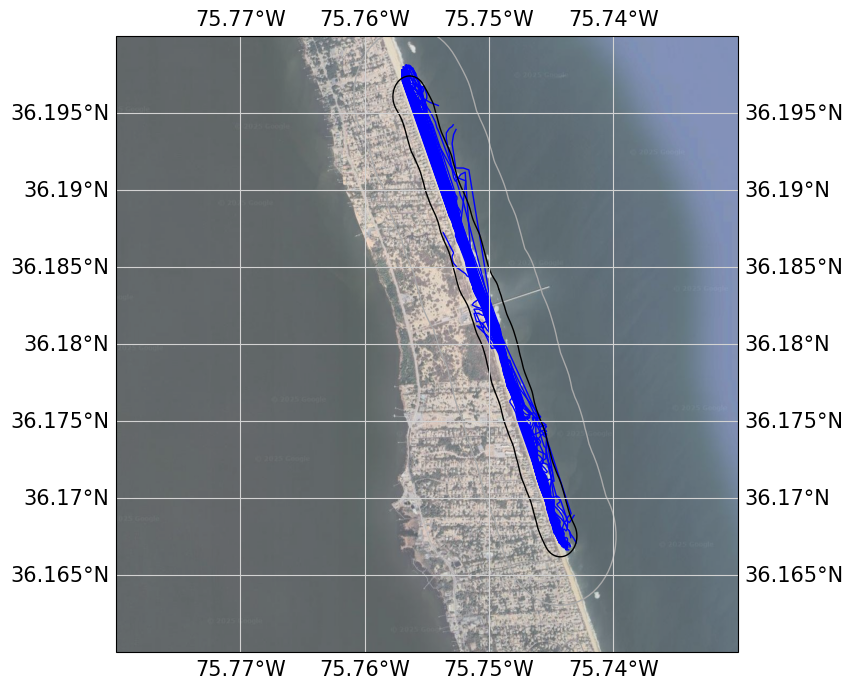

In [108]:
# Visual inspection of volume change area
projection = ccrs.PlateCarree()
extent = [-75.78, -75.73, 36.16, 36.2]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)

ax.add_geometries(poly_target, crs=projection, facecolor='none', edgecolor='darkgrey')
ax.add_geometries(poly_target_red, crs=projection, facecolor='none', edgecolor='black')

for sl in c_shorelines_corr:
    ax.add_geometries(LineString(sl), crs=projection, facecolor='none', edgecolor='blue', zorder=1, alpha=1)

In [29]:
rs_shoreline = {"dates":c_dates, "shorelines":c_shorelines_corr}
seg_length = 50 # [m]
seg_length = CD_geometry.dist_meter_to_dist_deg(seg_length) # [deg]

x_state, sigma_xx_up, sigma_xx_pred, updated_points, T = CD_kalman.forward_run(
    year_start, year_end, init, std_init, rs_shoreline, seg_length, alt,
    tidal_corr['corr_eot[m]'], epsg, T_is_identity, max_distance, w_id,
    max_noupdate, std_pseudobs, sigma_l, sigma_q, eps_factor)
        
x_state_s, sigma_xx_s = CD_kalman.backward_run(x_state, sigma_xx_up, sigma_xx_pred, year_end, T, eps_factor)       

kf_interp, rts_interp = CD_kalman.interpolate_results(vali_gdf, x_state, x_state_s, updated_points)

# Volume change time series
volumes, rmse, corr, pvalues, trends, errors = volume_changes(kf_interp, rts_interp, vali_gdf, poly_target_red)

## Tune

In [36]:
# sigma_l
# Minimum combined error
beach_slope_min = 0.001
rmse_h_cassie_min = 5
std_alt_min = 0.03
rms_eot20_min = 0.01 # from paper, table 3: 0.061
sigma_v_total_min = np.sqrt((beach_slope_min * rmse_h_cassie_min)**2 + std_alt_min**2 + rms_eot20_min**2)

# Maximum combined error
beach_slope_max = 0.02
rmse_h_cassie_max = 50
std_alt_max = .8
rms_eot20_max = 0.1
sigma_v_total_max = np.sqrt((beach_slope_max * rmse_h_cassie_max)**2 + std_alt_max**2 + rms_eot20_max**2)

print(f'Min: {round(sigma_v_total_min,2)} m, Max: {round(sigma_v_total_max,2)} m')

Min: 0.03 m, Max: 1.28 m


In [37]:
sigma_l_values =  np.linspace(sigma_v_total_min, sigma_v_total_max, 5) # [m]
factors = [1, 10, 25]
std_init_values = [1, 3, 9] # [m]

param_df = pd.DataFrame(list(itertools.product(factors, sigma_l_values, std_init_values)), columns=['factor', 'sigma_l', 'std_init'])

param_df['sigma_q'] = param_df['factor'] * param_df['sigma_l']
param_df

,factor,sigma_l,std_init,sigma_q
0,1,0.032016,1,0.032016
1,1,0.032016,3,0.032016
2,1,0.032016,9,0.032016
3,1,0.345143,1,0.345143
4,1,0.345143,3,0.345143
5,1,0.345143,9,0.345143
6,1,0.658269,1,0.658269
7,1,0.658269,3,0.658269
8,1,0.658269,9,0.658269
9,1,0.971396,1,0.971396


In [113]:
if new_tuning:
    rs_shoreline = {"dates":c_dates, "shorelines":c_shorelines_corr}
    seg_length = 50 # [m]
    seg_length = CD_geometry.dist_meter_to_dist_deg(seg_length) # [deg]

    # Store statistics for volume time series in DataFrames
    rmse_df = pd.DataFrame()
    corr_df = pd.DataFrame()
    pvalues_df = pd.DataFrame()
    trend_df = pd.DataFrame()
    errors_df = pd.DataFrame()

    # Store statistics for elevation time series in xarray DataSet
    # Initialise xarray DataSet to store the full map for all statistics and each combination of parameters
    lon = vali_gdf.geometry.x
    lat = vali_gdf.geometry.y
    
    empty_array = np.full([len(lon), len(sigma_l_values), len(factors), len(std_init_values)], np.nan)
    
    # Initialise the stats (collect all maps for all parameters) with NaN values
    all_stats = xr.Dataset(
                data_vars={
                    'std_diff':(['lon', 'sigma_l', 'factors', 'std_init'], empty_array.copy()),
                    'rmse':(['lon', 'sigma_l', 'factors', 'std_init'], empty_array.copy()),
                    'corr':(['lon', 'sigma_l', 'factors', 'std_init'], empty_array.copy()),
                    'pvalue':(['lon', 'sigma_l', 'factors', 'std_init'], empty_array.copy()),
                    'trend_diff':(['lon', 'sigma_l', 'factors', 'std_init'], empty_array.copy())
                },
                coords={
                    'lon':(['lon'], lon),
                    'lat':(['lat'], lat),
                    'sigma_l':(['sigma_l'], sigma_l_values),
                    'factors':(['factors'], factors),
                    'std_init':(['std_init'], std_init_values)
                })
    
    for i in param_df.index:
        factor = param_df.loc[i, 'factor']
        sigma_q = param_df.loc[i, 'sigma_q']
        sigma_l = param_df.loc[i, 'sigma_l']
        std_init = param_df.loc[i, 'std_init']
        print(f'{i}: factor = {factor}, sigma_l = {sigma_l}, std_init = {std_init}')

        x_state, sigma_xx_up, sigma_xx_pred, updated_points, T = CD_kalman.forward_run(
            year_start, year_end, init, std_init, rs_shoreline, seg_length, alt,
            tidal_corr['corr_eot[m]'], epsg, T_is_identity, max_distance, w_id,
            max_noupdate, std_pseudobs, sigma_l, sigma_q, eps_factor)

        x_state_s, sigma_xx_s = CD_kalman.backward_run(x_state, sigma_xx_up, sigma_xx_pred, year_end, T, eps_factor)       

        kf_interp, rts_interp = CD_kalman.interpolate_results(vali_gdf, x_state, x_state_s, updated_points)

        # Volume change time series
        volumes, rmse, corr, pvalues, trends, errors = volume_changes(kf_interp, rts_interp, vali_gdf, poly_target_red)
        
        rmse_df[i] = pd.DataFrame([rmse]).T[0]
        corr_df[i] = pd.DataFrame([corr]).T[0]
        pvalues_df[i] = pd.DataFrame([pvalues]).T[0]
        trend_df[i] = pd.DataFrame([trends]).T[0]
        errors_df[i] = pd.DataFrame([errors]).T[0]

        # save
        rmse_df.to_pickle(path_output+'partun_volumes_rmse.pkl')
        corr_df.to_pickle(path_output+'partun_volumes_corr.pkl')
        pvalues_df.to_pickle(path_output+'partun_volumes_pvalues.pkl')
        trend_df.to_pickle(path_output+'partun_volumes_trends.pkl')
        errors_df.to_pickle(path_output+'partun_volumes_errors.pkl')

        # Elevation change timeseries
        for vali_point in vali_gdf.index:
            lon = vali_gdf.iloc[vali_point].geometry.x
            rts_ts = rts_interp.drop(columns='geometry').iloc[vali_point]
            idx, = np.where(np.isin(vali_gdf.columns, rts_ts.index)) # where vali years and rts years overlap
            vali_ts = vali_gdf.loc[vali_point].iloc[idx].astype(float)
            
            not_nan = np.logical_or(np.isnan(rts_ts), vali_ts.isna())
            # if number of nan values more than 50 % of the total number of values
            if not_nan.sum() > len(rts_ts)/2: # at least 50 % overlapping non-nan values
                continue
                
            # RMSE
            all_stats['rmse'].loc[{'lon':lon, 'sigma_l':sigma_l, 'factors':factor, 'std_init':std_init}] = \
                CD_statistics.RMSE_timeseries(rts_ts, vali_ts)
            
            # Correlation
            all_stats['corr'].loc[{'lon':lon, 'sigma_l':sigma_l, 'factors':factor, 'std_init':std_init}], \
                all_stats['pvalue'].loc[{'sigma_l':sigma_l, 'factors':factor, 'std_init':std_init}] \
                = stats.pearsonr(vali_ts[~not_nan], rts_ts[~not_nan])
            
            # Trend in m/year, Cxx: cov.matrix, v: diff between observations and model
            trend_rts, _, _ = CD_statistics.compute_trend_with_error(rts_ts.index.values.astype(int), rts_ts.values)
            trend_vali, _, _ = CD_statistics.compute_trend_with_error(vali_ts.index.values.astype(int), vali_ts.values)
            
            all_stats['trend_diff'].loc[{'lon':lon, 'sigma_l':sigma_l, 'factors':factor, 'std_init':std_init}] = trend_rts - trend_vali
                
    all_stats.to_netcdf(f'{path_output}partun_elevs_all_stats.nc')
        
else:
    rmse_df = pd.read_pickle(path_output+'partun_volumes_rmse.pkl')
    corr_df = pd.read_pickle(path_output+'partun_volumes_corr.pkl')
    pvalues_df = pd.read_pickle(path_output+'partun_volumes_pvalues.pkl')
    trend_df = pd.read_pickle(path_output+'partun_volumes_trends.pkl')
    errors_df = pd.read_pickle(path_output+'partun_volumes_errors.pkl')
    print("Loaded files.")

    all_stats = xr.open_dataset(f'{path_output}partun_elevs_all_stats.nc')
    print(f'Loaded {path_output}partun_elevs_all_stats.nc')

0: factor = 1, sigma_l = 0.032015621187164243, std_init = 1
Forward run done. Needed  6.2 seconds.
Backward run done. Needed  1.2 seconds.
Interpolation done. Needed  1.8 seconds.
Volume changes done. Needed  0.1 seconds.
1: factor = 1, sigma_l = 0.032015621187164243, std_init = 3
Forward run done. Needed  6.2 seconds.
Backward run done. Needed  1.2 seconds.
Interpolation done. Needed  1.8 seconds.
Volume changes done. Needed  0.1 seconds.
2: factor = 1, sigma_l = 0.032015621187164243, std_init = 9
Forward run done. Needed  6.3 seconds.
Backward run done. Needed  1.2 seconds.
Interpolation done. Needed  1.8 seconds.
Volume changes done. Needed  0.1 seconds.
3: factor = 1, sigma_l = 0.3451425303570014, std_init = 1
Forward run done. Needed  6.2 seconds.
Backward run done. Needed  1.2 seconds.
Interpolation done. Needed  1.8 seconds.
Volume changes done. Needed  0.1 seconds.
4: factor = 1, sigma_l = 0.3451425303570014, std_init = 3
Forward run done. Needed  6.2 seconds.
Backward run done

## Plots

In [114]:
cmap = cm['Blues_r']
c_list = cmap(np.linspace(0,.6,3))
# c_list = ['purple', 'darkblue', 'limegreen'] # encode sigma_q (factors of sigma_l) with colour
ls_list = ['-', '-.', ':'] # encode sigma_gebco with linestyle

In [115]:
def plot_legend(ax, c_list, ls_list, factors, std_init_values):
    legend_elements = [Line2D([0], [0], color=c_list[0], label=f'factor={factors[0]}'),
                   Line2D([0], [0], color=c_list[1], label=f'factor={factors[1]}'),
                   Line2D([0], [0], color=c_list[2], label=f'factor={factors[2]}'),

                   Line2D([0], [0], color='grey', ls=ls_list[0], label=f'std_init={std_init_values[0]}'),
                   Line2D([0], [0], color='grey', ls=ls_list[1], label=f'std_init={std_init_values[1]}'),
                   Line2D([0], [0], color='grey', ls=ls_list[2], label=f'std_init={std_init_values[2]}'),
                      
                  Line2D([0], [0], marker='o', lw=0, ms=10, color='grey', label='p-value < 0.05')]
    ax.legend(handles=legend_elements, bbox_to_anchor=(1,1))

### Volume changes

In [117]:
def plot_vol_stats(ax, data, area, ylabel, title, corr=False, plot_zero=False, ylim=None):
    for f, factor in enumerate(factors):
        for g, std_init in enumerate(std_init_values):
            idx, = np.where((param_df.factor == factor) & (param_df.std_init == std_init))
            ax.plot(param_df.loc[idx, 'sigma_l'], data[idx], ls=ls_list[g], c=c_list[f], marker='.')
            
            if corr:
                pvalues_box, = np.where(pvalues_df.T.loc[idx, area] < 0.05)
                ax.plot(param_df['sigma_l'][pvalues_box], corr_df.loc[area][pvalues_box], marker='o', lw=0, ms=10, color='grey', label='p-value < 0.05')

            if plot_zero:
                ax.axhline(y=0, color='grey')            

    if ylim != None:
        ax.set_ylim(ylim[0], ylim[1])

    if not corr:
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        # ax.ticklabel_format(useOffset=False, style='plain')
    
    ax.set_xlabel('sigma_l [m]')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=22)
    ax.grid()

In [119]:
trend_diff = pd.DataFrame()
trend_diff['all'] = trend_df.T['rts'] - trend_df.T['vali']

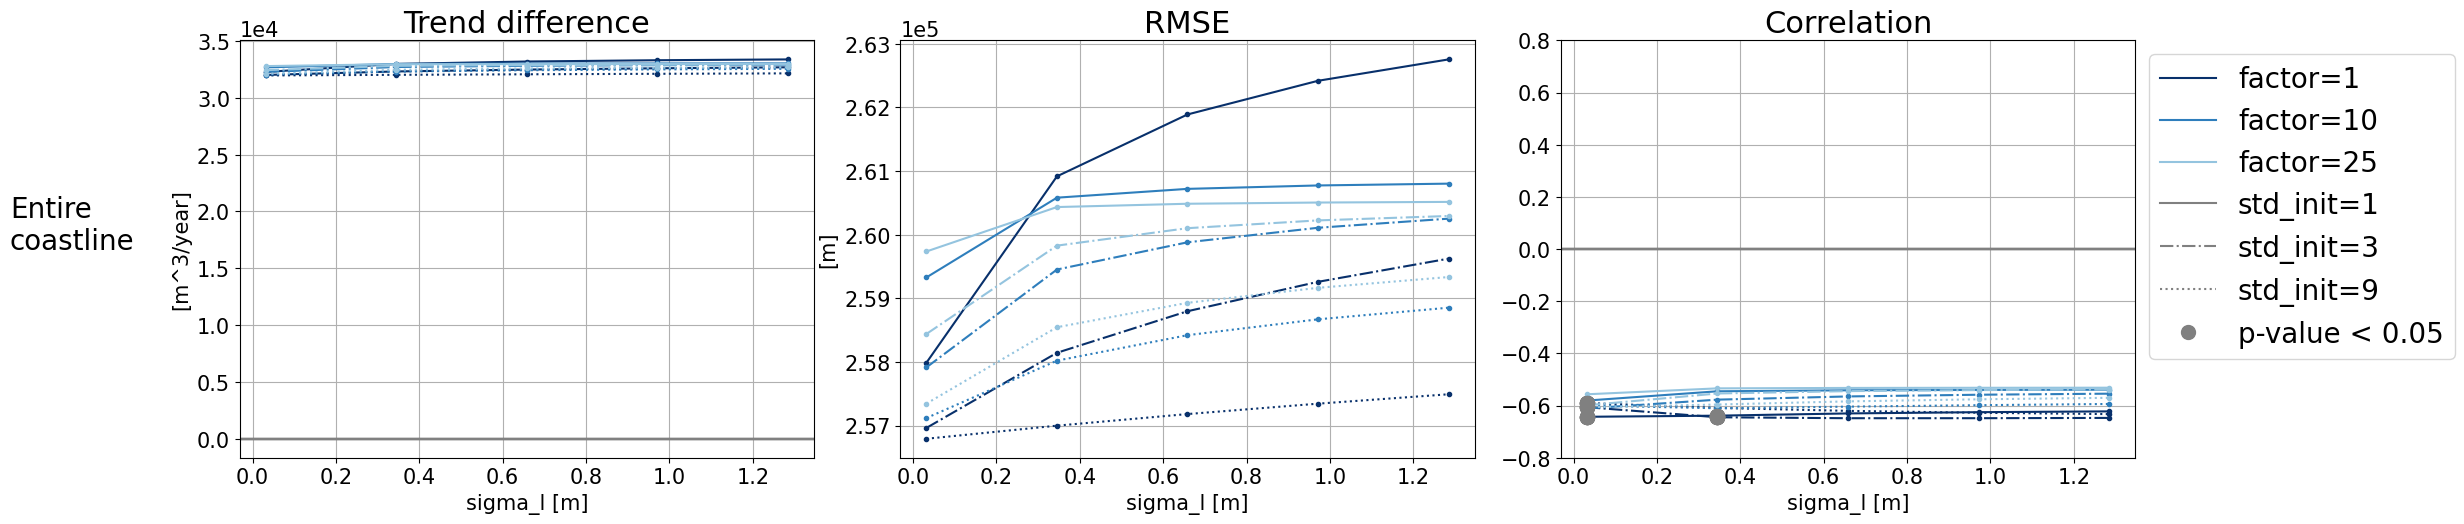

In [134]:
fig, axs = plt.subplots(1,3, figsize=(20,5))
fig.tight_layout()
fig.subplots_adjust(hspace=.3, wspace=.15)

plot_vol_stats(axs[0], trend_diff['all'], area=0, ylabel='[m^3/year]', title='Trend difference', plot_zero=True)
axs[1].text(-.4,.5, f'Entire\ncoastline', transform=axs[0].transAxes, fontsize=20)
plot_vol_stats(axs[1], rmse_df.T[0], area=0, ylabel='[m]', title='RMSE')
ylim_corr = [-.8, .8]
plot_vol_stats(axs[2], corr_df.T[0], area=0, ylabel='', title='Correlation', corr=True, plot_zero=True, ylim=ylim_corr)
plot_legend(axs[2], c_list, ls_list, factors, std_init_values)

# plt.savefig(f'{path_output}partun_volume_change_stats.png', dpi=300, bbox_inches='tight')

### Elevation changes

In [135]:
def plot_elev_stats(ax, stats_data, stats_varname, ylabel, title, corr=False, plot_zero=False, ylim=None):
    for f, factor in enumerate(factors):
        for g, std_init in enumerate(std_init_values):
            ax.plot(stats_data.sigma_l, stats_data[stats_varname].loc[{'factors':factor, 'std_init':std_init}].mean(dim='lon'), ls=ls_list[g], c=c_list[f], marker='.')
            if corr:
                pvalues_box, = np.where(stats_data.pvalue.loc[{'factors':factor, 'std_init':std_init}].mean(dim='lon') < 0.05)
                ax.plot(stats_data.sigma_l[pvalues_box], stats_data.corr.loc[{'factors':factor, 'std_init':std_init}].mean(dim='lon')[pvalues_box], 
                marker='o', lw=0, ms=10, color='grey', label='p-value < 0.05')
            if ylim is not None:
                ax.set_ylim(ylim)
            if plot_zero:
                ax.axhline(y=0, color='grey')
    ax.set_xlabel('sigma_l [m]')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid()

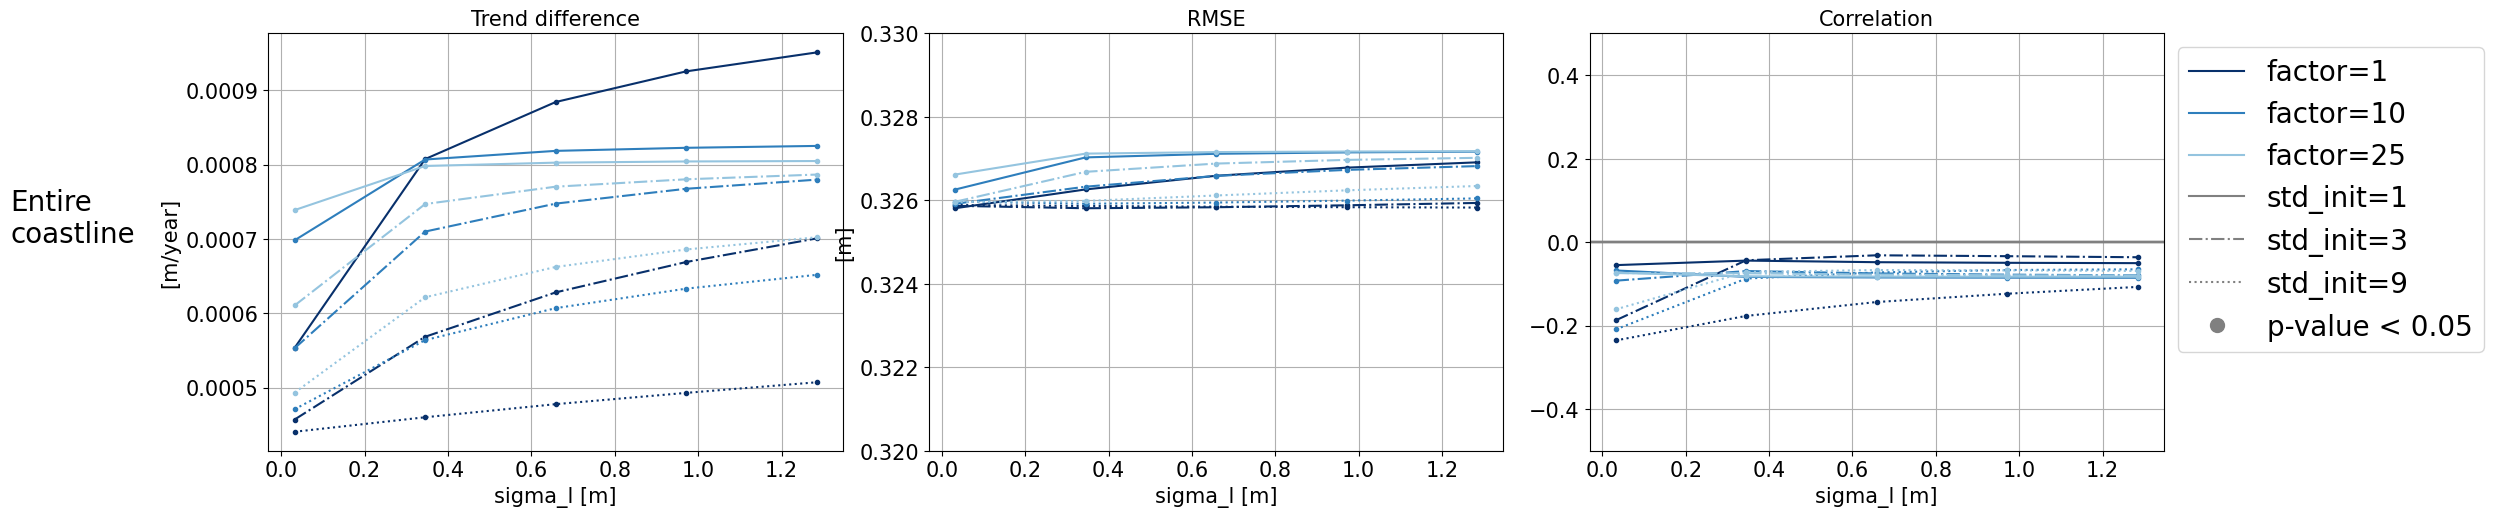

In [149]:
fig, axs = plt.subplots(1,3, figsize=(20,5))
fig.tight_layout()
fig.subplots_adjust(hspace=.3, wspace=.15)

plot_elev_stats(axs[0], all_stats, 'trend_diff', ylabel='[m/year]', title='Trend difference', plot_zero=False)

axs[0].text(-.45,.5, f'Entire\ncoastline', transform=axs[0].transAxes, fontsize=20)

ylim_rmse = [.32,.33]
plot_elev_stats(axs[1], all_stats, 'rmse', ylabel='[m]', title='RMSE', ylim=ylim_rmse)

ylim_corr = [-.5,.5]
plot_elev_stats(axs[2], all_stats, 'corr', ylabel='', title='Correlation', corr=True, plot_zero=True, ylim=ylim_corr)

plot_legend(axs[2], c_list, ls_list, factors, std_init_values)

plt.savefig(f'{path_output}partun_elev_change_stats.png', dpi=300, bbox_inches='tight')